## Assignment No.8

## Logistic Regression

(768, 9)
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  


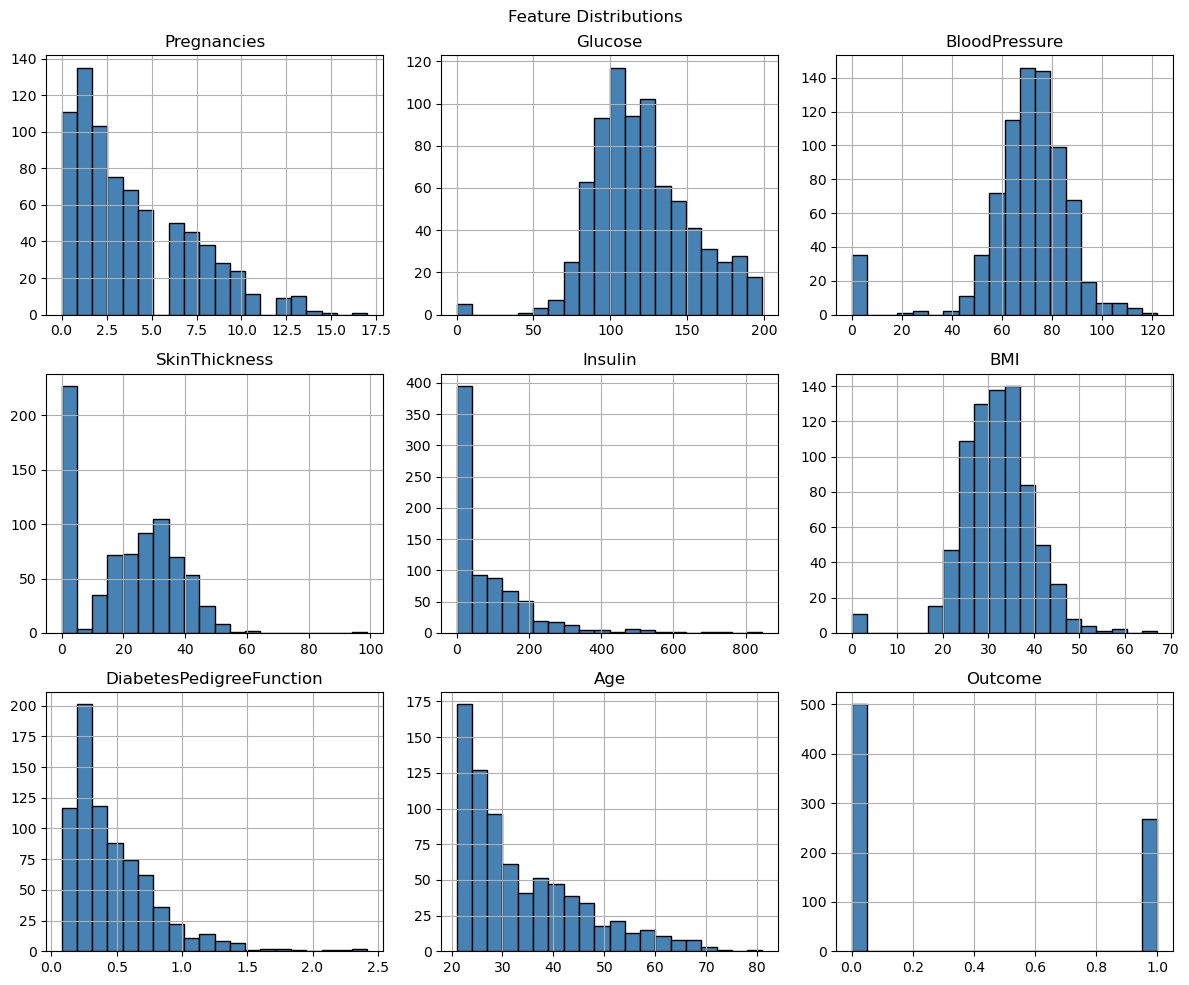

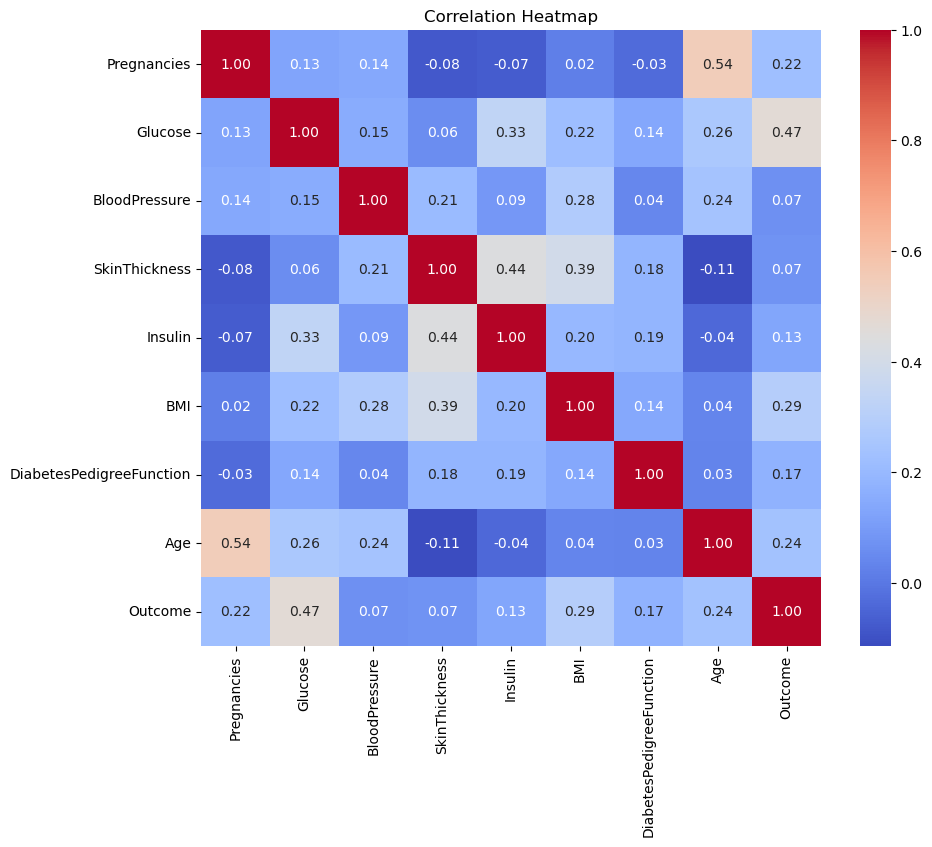

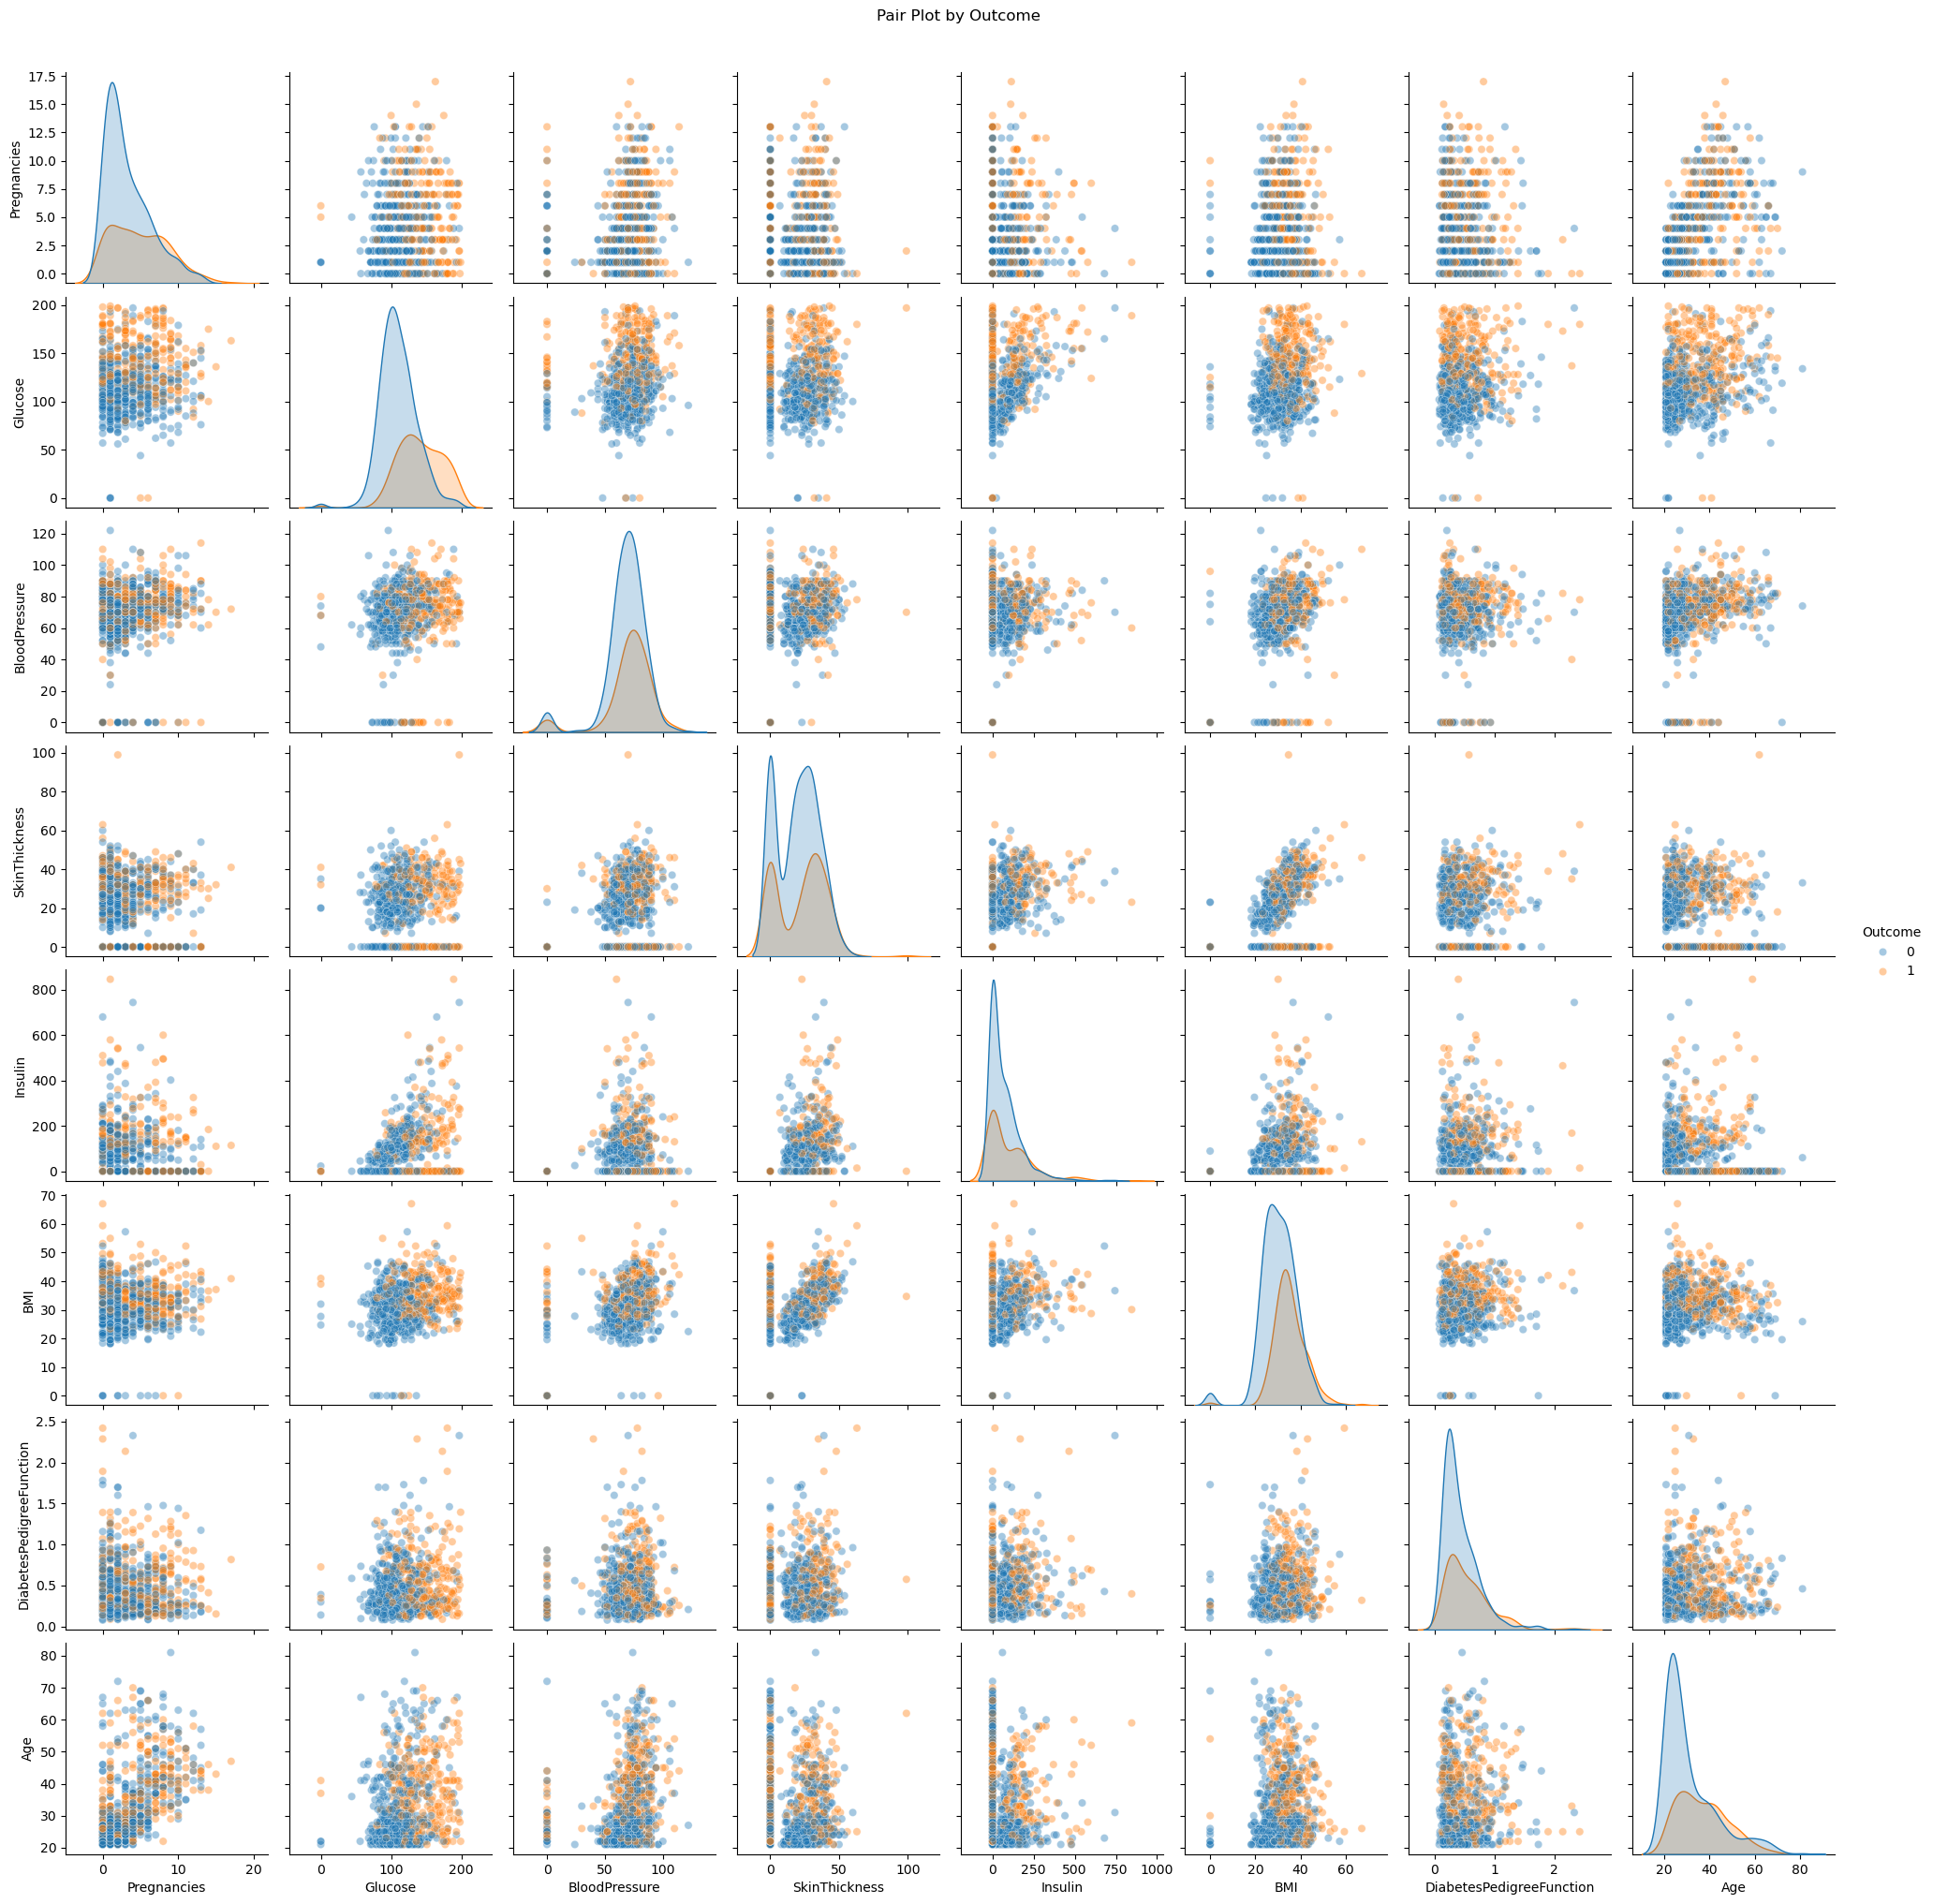

C:\Users\dipak\AppData\Local\Temp\ipykernel_11836\1144372428.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i//4][i%4].boxplot([df[df['Outcome']==0][col], df[df['Outcome']==1][col]], labels=['No Diabetes','Diabetes'])
C:\Users\dipak\AppData\Local\Temp\ipykernel_11836\1144372428.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i//4][i%4].boxplot([df[df['Outcome']==0][col], df[df['Outcome']==1][col]], labels=['No Diabetes','Diabetes'])
C:\Users\dipak\AppData\Local\Temp\ipykernel_11836\1144372428.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i//4][i%4].boxplot([df[df['Outcome']==0][col], d

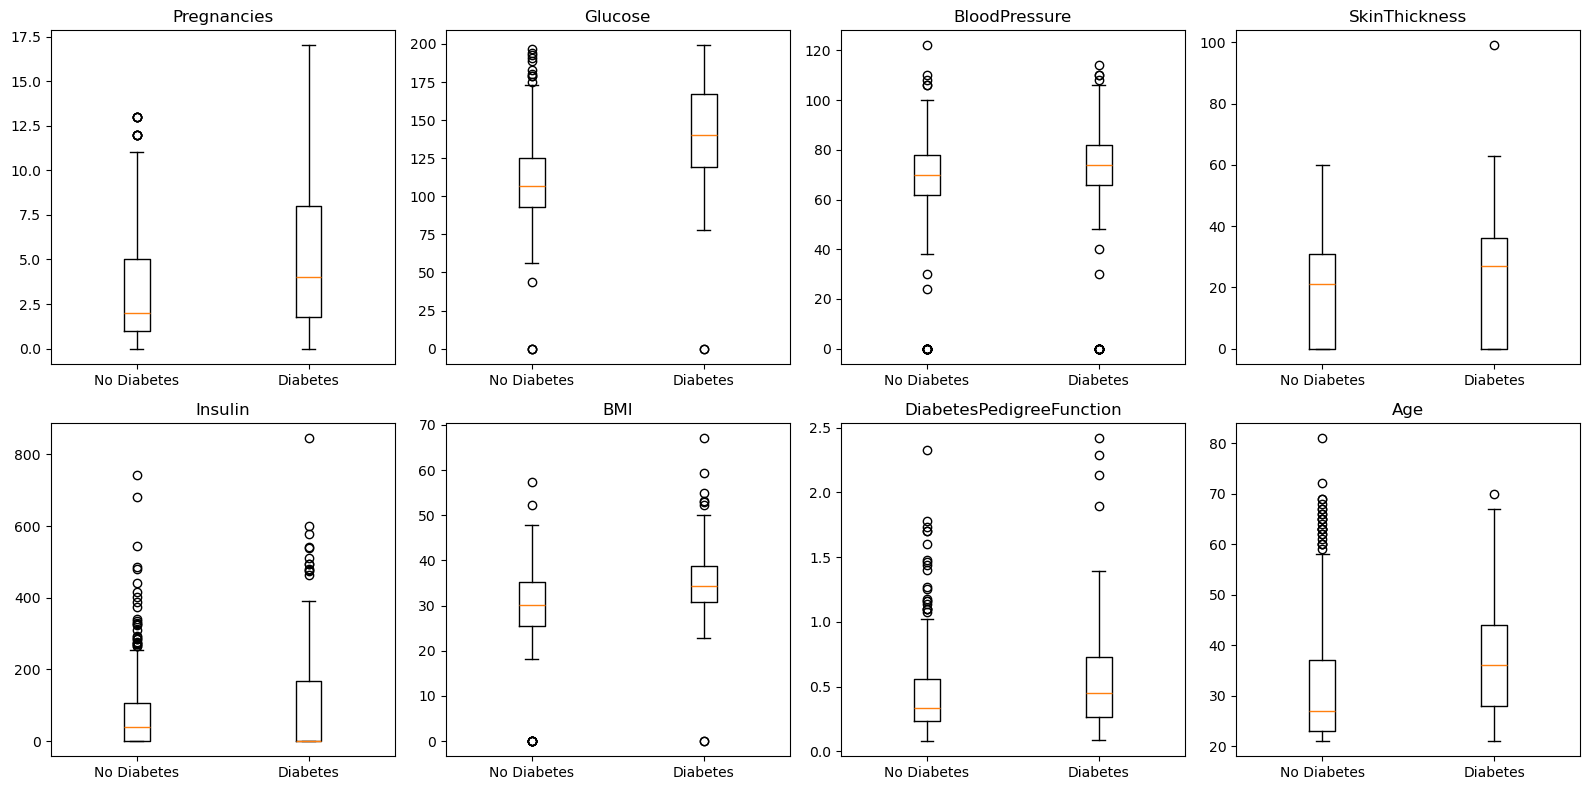

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes.csv")

print(df.shape)
print(df.dtypes)
print(df.head())
print(df.describe())
print(df.isnull().sum())
print(df['Outcome'].value_counts())

df.hist(figsize=(12, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df, hue='Outcome', diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle("Pair Plot by Outcome", y=1.02)
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
for i, col in enumerate(features):
    axes[i//4][i%4].boxplot([df[df['Outcome']==0][col], df[df['Outcome']==1][col]], labels=['No Diabetes','Diabetes'])
    axes[i//4][i%4].set_title(col)
plt.tight_layout()
plt.show()

In [4]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)

print("Missing values after replacing zeros:")
print(df.isnull().sum())

for col in zero_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:")
print(df.isnull().sum())

print(df.describe())

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.00

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

print("Model trained successfully.")
print(f"Training Accuracy: {model.score(X_train_sc, y_train):.4f}")

Model trained successfully.
Training Accuracy: 0.7704


Accuracy : 0.7532467532467533
Precision: 0.6666666666666666
Recall   : 0.6181818181818182
F1 Score : 0.6415094339622641
ROC-AUC  : 0.82277318640955

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



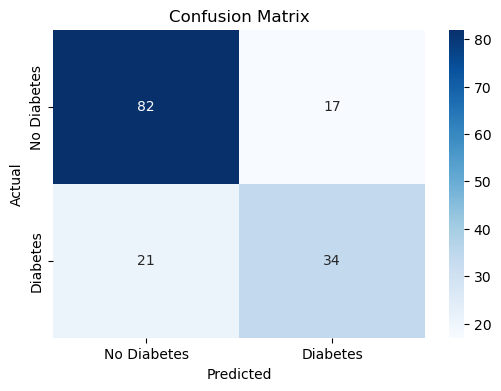

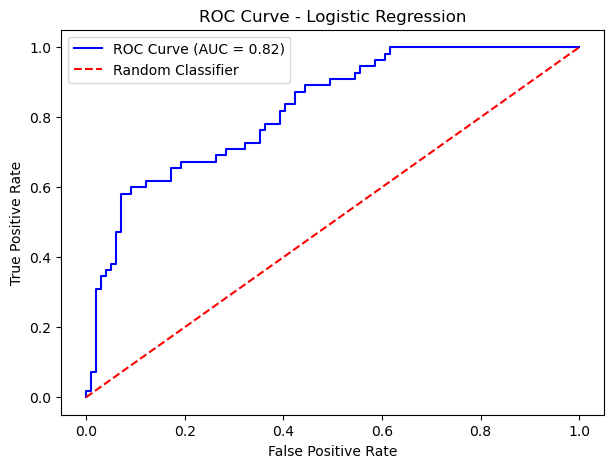

In [10]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, roc_curve)

y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

                    Feature  Coefficient
1                   Glucose     1.102682
5                       BMI     0.688839
7                       Age     0.392410
0               Pregnancies     0.222978
6  DiabetesPedigreeFunction     0.203635
3             SkinThickness     0.068836
4                   Insulin    -0.138252
2             BloodPressure    -0.151540

Intercept: -0.8768


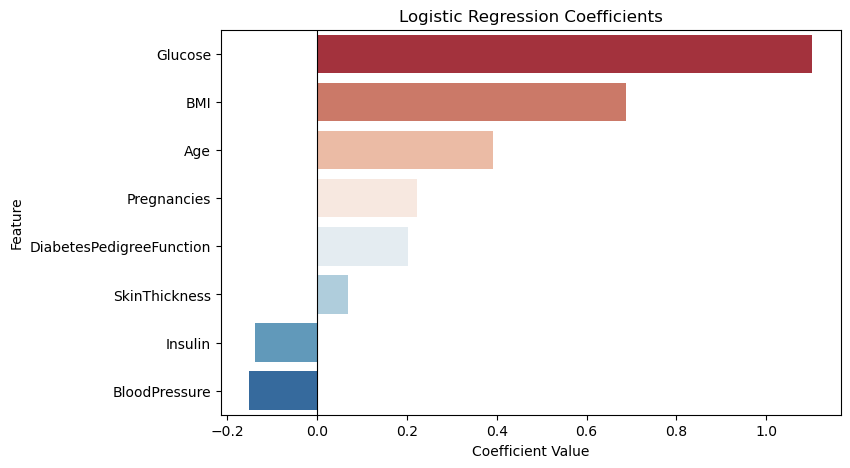

In [14]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coeff_df)
print(f"\nIntercept: {model.intercept_[0]:.4f}")

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coeff_df,
            hue='Feature', palette='RdBu', legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.show()

## FEATURE SIGNIFICANCE DISCUSSION
=================================

1. GLUCOSE (Coefficient = +1.1027) — Most Significant
   Glucose level is by far the most important predictor of diabetes.
   High blood glucose is the defining characteristic of diabetes mellitus.
   A person with high glucose is ~3x more likely to be diabetic.

2. BMI (Coefficient = +0.6888) — Highly Significant
   Obesity is a major risk factor for Type 2 diabetes.
   Higher body mass leads to insulin resistance, which causes diabetes.
   A 1-standard-deviation increase in BMI nearly doubles the odds.

3. AGE (Coefficient = +0.3924) — Significant
   Risk of Type 2 diabetes increases with age.
   Older adults have reduced insulin sensitivity and pancreatic function.

4. PREGNANCIES (Coefficient = +0.2230) — Moderately Significant
   Multiple pregnancies increase risk due to gestational diabetes history.
   Women who had gestational diabetes are at higher lifetime risk.

5. DIABETES PEDIGREE FUNCTION (Coefficient = +0.2036) — Moderately Significant
   Represents genetic and family history contribution to diabetes risk.
   Even a moderate family history meaningfully increases risk.

6. SKIN THICKNESS (Coefficient = +0.0688) — Weakly Significant
   A proxy for body fat distribution. Weak effect after controlling for BMI.

7. INSULIN (Coefficient = -0.1383) — Counterintuitive
   Negative coefficient is due to multicollinearity with Glucose and BMI.
   In isolation, high insulin would suggest higher risk, but in a multivariate
   model it adjusts to reflect suppression effects between correlated features.

8. BLOOD PRESSURE (Coefficient = -0.1515) — Weak Negative
   Weak effect in this model. Blood pressure alone is not a strong predictor
   after accounting for BMI, Age, and Glucose simultaneously.

CONCLUSION:
The three most clinically meaningful predictors are Glucose, BMI, and Age.
This aligns with medical literature — these are the primary risk factors
for Type 2 Diabetes used in clinical screening worldwide (e.g., ADA guidelines).

In [16]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_scaled = scaler.fit_transform(X)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X_scaled, y, cv=skf, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print(f"Mean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Deviation : {cv_scores.std():.4f}")

cv_f1 = cross_val_score(model, X_scaled, y, cv=skf, scoring='f1')
print(f"\nMean F1 Score : {cv_f1.mean():.4f}")

cv_roc = cross_val_score(model, X_scaled, y, cv=skf, scoring='roc_auc')
print(f"Mean ROC-AUC  : {cv_roc.mean():.4f}")

Cross-Validation Accuracy Scores: [0.77272727 0.7987013  0.77922078 0.75163399 0.76470588]
Mean Accuracy : 0.7734
Std Deviation : 0.0156

Mean F1 Score : 0.6371
Mean ROC-AUC  : 0.8366


# Q1: What is the difference between Precision and Recall?

Both Precision and Recall are evaluation metrics used in classification problems.

PRECISION:
Precision tells us: Out of all the cases the model predicted as Positive, how many were actually Positive?
Formula: Precision = True Positives / (True Positives + False Positives)
Example: Out of 100 patients predicted as Diabetic, 80 were actually Diabetic.
Precision = 80 / 100 = 0.80

RECALL (Sensitivity):
Recall tells us: Out of all the actual Positive cases, how many did the model correctly identify?
Formula: Recall = True Positives / (True Positives + False Negatives)
Example: Out of 90 patients who are actually Diabetic, the model correctly identified 80.
Recall = 80 / 90 = 0.89

WHEN TO USE WHICH:
Use HIGH PRECISION when false positives are costly.
  Example: Spam detection - you don't want to mark real emails as spam.
Use HIGH RECALL when false negatives are costly.
  Example: Diabetes detection - you don't want to miss a real diabetic patient.

In our diabetes dataset, RECALL is more important.
Missing a diabetic patient (False Negative) is more dangerous than
wrongly classifying a healthy person as diabetic (False Positive).

F1 SCORE balances both:
F1 = 2 x (Precision x Recall) / (Precision + Recall)

# Q2: What is Cross-Validation and why is it important in binary classification?

WHAT IS CROSS-VALIDATION:
Cross-validation is a technique to evaluate a model by training and testing it on
multiple different subsets of the data instead of just one fixed train-test split.

HOW K-FOLD CROSS-VALIDATION WORKS:
1. Split the dataset into K equal parts (folds). Example: K = 5
2. In each round, use 1 fold as test set and the remaining K-1 folds as training set
3. Train and evaluate the model K times, each time using a different fold as the test set
4. Average the K evaluation scores to get the final performance estimate

Example with K=5 and 768 rows:
  Fold 1: Train on rows 2-768, Test on rows 1-154
  Fold 2: Train on rows 1-154 and 309-768, Test on rows 155-308
  ... and so on for all 5 folds

WHY IT IS IMPORTANT IN BINARY CLASSIFICATION:
1. More reliable estimate: A single train-test split might get lucky or unlucky.
   Cross-validation averages over multiple splits for a more reliable score.

2. Handles class imbalance: In our dataset, 65% are Non-Diabetic and 35% are Diabetic.
   Stratified K-Fold ensures each fold has the same class ratio as the full dataset.

3. Uses all data for both training and testing: Every row is used for testing exactly once.
   This is useful when the dataset is small (like our 768-row dataset).

4. Detects overfitting: If training accuracy is high but cross-validation accuracy is low,
   the model is overfitting. Cross-validation catches this early.

In [ ]:
#streamlt
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

st.set_page_config(page_title="Diabetes Predictor", layout="centered")

df = pd.read_csv("diabetes-2.csv")
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_scaled, y)

st.title("Diabetes Prediction App")
st.markdown("Enter patient details below to predict diabetes outcome.")

col1, col2 = st.columns(2)
with col1:
    pregnancies    = st.number_input("Pregnancies", 0, 20, 1)
    glucose        = st.number_input("Glucose", 0, 300, 120)
    blood_pressure = st.number_input("Blood Pressure", 0, 200, 70)
    skin_thickness = st.number_input("Skin Thickness", 0, 100, 20)
with col2:
    insulin = st.number_input("Insulin", 0, 900, 80)
    bmi     = st.number_input("BMI", 0.0, 70.0, 25.0)
    dpf     = st.number_input("Diabetes Pedigree Function", 0.0, 3.0, 0.5)
    age     = st.number_input("Age", 1, 120, 30)

if st.button("Predict"):
    input_data   = np.array([[pregnancies, glucose, blood_pressure, skin_thickness, insulin, bmi, dpf, age]])
    input_scaled = scaler.transform(input_data)
    prediction   = model.predict(input_scaled)[0]
    probability  = model.predict_proba(input_scaled)[0][1]

    if prediction == 1:
        st.error(f"Result: Diabetic   |   Probability: {probability:.2%}")
    else:
        st.success(f"Result: Not Diabetic   |   Probability of Diabetes: {probability:.2%}")